## 1. Analysis Plan

The analysis will be performed in the following stages:

1. Load and inspect the dataset.
2. Examine the distribution of `total_bill`.
3. Perform Shapiro-Wilk and Kolmogorov-Smirnov normality tests.
4. Compare `total_bill` between smokers and non-smokers using an independent two-sample t-test and Mann-Whitney U test.
5. Perform One-Way ANOVA to compare `total_bill` across days.
6. Perform Two-Way ANOVA to examine the effects of gender and meal time on `tip`.
7. Perform Tukey HSD post-hoc analysis where appropriate.
8. Report confidence intervals and statistical findings.

# Task 3 — Advanced Statistical Analysis & Hypothesis Testing

## Objective

This notebook performs statistical analysis and hypothesis testing using the `tips` dataset.

The analysis includes:

- Normality testing
- Independent two-sample t-test
- Mann-Whitney U test
- One-Way ANOVA
- Two-Way ANOVA
- Tukey HSD post-hoc analysis
- Confidence intervals
- Distribution plots
- Statistical findings

## Dataset

The `tips` dataset contains restaurant transaction information including:

- Total bill
- Tip
- Gender
- Smoker status
- Day
- Time
- Party size

## Significance Level

α = 0.05

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = sns.load_dataset("tips")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 244
Columns: 7


In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(244, 7)

Column Names:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Data Types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [7]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


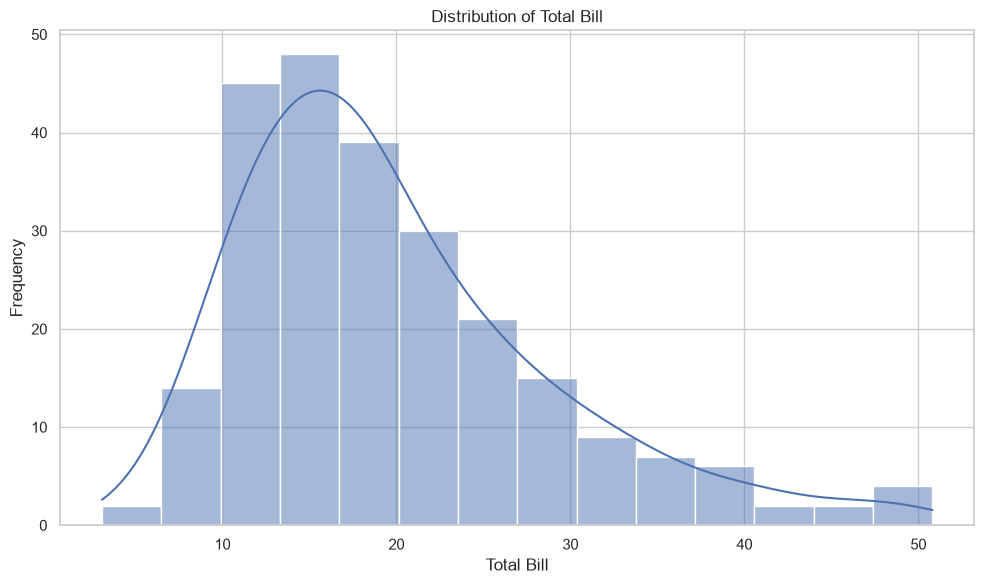

Plot saved successfully to: ..\plots\day02_total_bill_distribution.png


In [21]:
from pathlib import Path

plots_dir = Path("../plots")
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

sns.histplot(
    df["total_bill"],
    kde=True
)

plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.tight_layout()

plot_file = plots_dir / "day02_total_bill_distribution.png"
plt.savefig(plot_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved successfully to: {plot_file}")

In [11]:
total_bill = df["total_bill"].dropna()

shapiro_stat, shapiro_p = stats.shapiro(total_bill)

print("Shapiro-Wilk Normality Test")
print("---------------------------")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.6f}")

Shapiro-Wilk Normality Test
---------------------------
Statistic: 0.9197
p-value: 0.000000


In [12]:
alpha = 0.05

if shapiro_p < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: There is evidence that total_bill is not normally distributed.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: There is insufficient evidence to conclude that total_bill is not normally distributed.")

Decision: Reject H₀
Conclusion: There is evidence that total_bill is not normally distributed.


In [14]:
standardized_bill = (
    total_bill - total_bill.mean()
) / total_bill.std(ddof=1)

ks_stat, ks_p = stats.kstest(
    standardized_bill,
    "norm"
)

print("Kolmogorov-Smirnov Normality Test")
print("---------------------------------")
print(f"Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.6f}")

Kolmogorov-Smirnov Normality Test
---------------------------------
Statistic: 0.1188
p-value: 0.001866


In [15]:
if ks_p < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: There is evidence that total_bill is not normally distributed.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: There is insufficient evidence to conclude that total_bill is not normally distributed.")

Decision: Reject H₀
Conclusion: There is evidence that total_bill is not normally distributed.


In [14]:
normality_results = pd.DataFrame({
    "Test": [
        "Shapiro-Wilk",
        "Kolmogorov-Smirnov"
    ],
    "Variable": [
        "total_bill",
        "total_bill"
    ],
    "Statistic": [
        shapiro_stat,
        ks_stat
    ],
    "p_value": [
        shapiro_p,
        ks_p
    ],
    "Alpha": [
        alpha,
        alpha
    ],
    "Decision": [
        "Reject H0" if shapiro_p < alpha else "Fail to reject H0",
        "Reject H0" if ks_p < alpha else "Fail to reject H0"
    ]
})

normality_results

,Test,Variable,Statistic,p_value,Alpha,Decision
0,Shapiro-Wilk,total_bill,0.919719,3.324539e-10,0.05,Reject H0
1,Kolmogorov-Smirnov,total_bill,0.118754,1.866364e-03,0.05,Reject H0


In [15]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

output_file = results_dir / "day02_normality_results.csv"

normality_results.to_csv(output_file, index=False)

print(f"Results saved successfully to: {output_file}")

Results saved successfully to: ..\results\day02_normality_results.csv


In [16]:
saved_results = pd.read_csv("../results/day02_normality_results.csv")

print("Saved results:")
print(saved_results)

Saved results:
                 Test    Variable  Statistic       p_value  Alpha   Decision
0        Shapiro-Wilk  total_bill   0.919719  3.324539e-10   0.05  Reject H0
1  Kolmogorov-Smirnov  total_bill   0.118754  1.866364e-03   0.05  Reject H0


# Day 3 — Two-Group Hypothesis Testing

## Objective

The objective of Day 3 is to compare restaurant bills between smokers and non-smokers using two statistical methods:

1. Independent two-sample t-test
2. Mann-Whitney U test

### Research Question

Is there a statistically significant difference in `total_bill` between smokers and non-smokers?

### Null Hypothesis (H₀)

There is no statistically significant difference in `total_bill` between smokers and non-smokers.

### Alternative Hypothesis (H₁)

There is a statistically significant difference in `total_bill` between smokers and non-smokers.

### Significance Level

α = 0.05

In [5]:
# Inspect smoker groups

print("Smoker Group Counts:")
print(df["smoker"].value_counts())

print("\nGroup Statistics:")
group_stats = df.groupby("smoker")["total_bill"].agg(
    ["count", "mean", "std", "median"]
)

group_stats

Smoker Group Counts:
smoker
No     151
Yes     93
Name: count, dtype: int64

Group Statistics:


,count,mean,std,median
smoker,,,,
Yes,93,20.756344,9.832154,17.92
No,151,19.188278,8.255582,17.59


In [16]:
# Independent two-sample t-test

smoker_yes = df.loc[df["smoker"] == "Yes", "total_bill"].dropna()
smoker_no = df.loc[df["smoker"] == "No", "total_bill"].dropna()

t_stat, t_p = stats.ttest_ind(
    smoker_yes,
    smoker_no,
    equal_var=False
)

print("Independent Two-Sample t-Test")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(t_p, 6))

if t_p < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: There is evidence of a statistically significant difference in total_bill between smokers and non-smokers.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: There is not enough evidence of a statistically significant difference in total_bill between smokers and non-smokers.")

Independent Two-Sample t-Test
t-statistic: 1.2843
p-value: 0.200805
Decision: Fail to reject H₀
Conclusion: There is not enough evidence of a statistically significant difference in total_bill between smokers and non-smokers.


In [17]:
# Mann-Whitney U test

u_stat, u_p = stats.mannwhitneyu(
    smoker_yes,
    smoker_no,
    alternative="two-sided"
)

print("Mann-Whitney U Test")
print("U-statistic:", round(u_stat, 4))
print("p-value:", round(u_p, 6))

if u_p < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: There is evidence of a statistically significant difference in total_bill between smokers and non-smokers.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: There is not enough evidence of a statistically significant difference in total_bill between smokers and non-smokers.")

Mann-Whitney U Test
U-statistic: 7531.5
p-value: 0.341334
Decision: Fail to reject H₀
Conclusion: There is not enough evidence of a statistically significant difference in total_bill between smokers and non-smokers.


In [18]:
# Compare the two statistical tests

two_group_results = pd.DataFrame({
    "Test": [
        "Welch Two-Sample t-Test",
        "Mann-Whitney U Test"
    ],
    "Statistic": [
        t_stat,
        u_stat
    ],
    "p_value": [
        t_p,
        u_p
    ],
    "Alpha": [
        alpha,
        alpha
    ],
    "Decision": [
        "Reject H₀" if t_p < alpha else "Fail to reject H₀",
        "Reject H₀" if u_p < alpha else "Fail to reject H₀"
    ]
})

two_group_results

,Test,Statistic,p_value,Alpha,Decision
0,Welch Two-Sample t-Test,1.284252,0.200805,0.05,Fail to reject H₀
1,Mann-Whitney U Test,7531.500000,0.341334,0.05,Fail to reject H₀


In [19]:
# 95% Confidence Interval for Difference in Means

mean_yes = smoker_yes.mean()
mean_no = smoker_no.mean()

difference = mean_yes - mean_no

# Welch's standard error
se = np.sqrt(
    smoker_yes.var(ddof=1) / len(smoker_yes)
    + smoker_no.var(ddof=1) / len(smoker_no)
)

# Welch-Satterthwaite degrees of freedom
df_welch = (
    (smoker_yes.var(ddof=1) / len(smoker_yes)
     + smoker_no.var(ddof=1) / len(smoker_no)) ** 2
    /
    (
        (smoker_yes.var(ddof=1) / len(smoker_yes)) ** 2 / (len(smoker_yes) - 1)
        +
        (smoker_no.var(ddof=1) / len(smoker_no)) ** 2 / (len(smoker_no) - 1)
    )
)

confidence_level = 0.95
alpha_ci = 1 - confidence_level

critical_value = stats.t.ppf(
    1 - alpha_ci / 2,
    df_welch
)

margin_of_error = critical_value * se

ci_lower = difference - margin_of_error
ci_upper = difference + margin_of_error

print("95% Confidence Interval for Difference in Means")
print("Mean (Smokers):", round(mean_yes, 4))
print("Mean (Non-Smokers):", round(mean_no, 4))
print("Difference in Means:", round(difference, 4))
print("95% CI Lower:", round(ci_lower, 4))
print("95% CI Upper:", round(ci_upper, 4))

95% Confidence Interval for Difference in Means
Mean (Smokers): 20.7563
Mean (Non-Smokers): 19.1883
Difference in Means: 1.5681
95% CI Lower: -0.8422
95% CI Upper: 3.9784


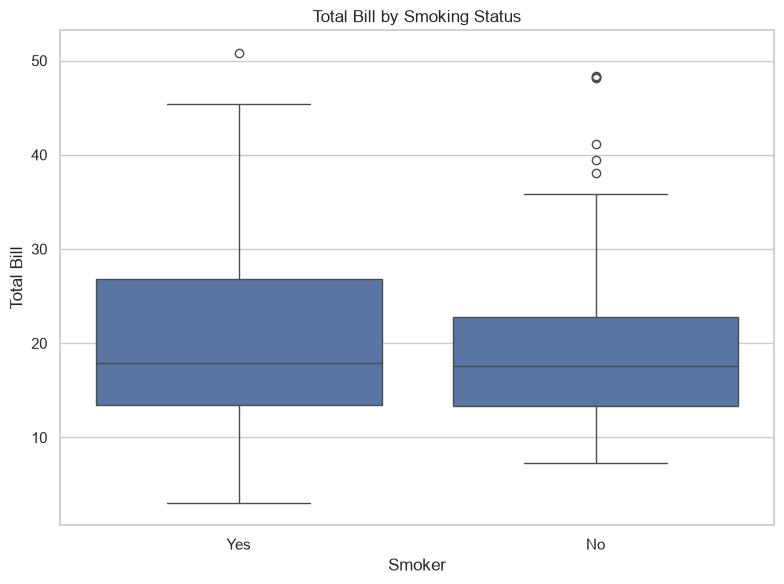

Plot saved successfully to: ..\plots\day03_total_bill_by_smoker.png


In [22]:
# Boxplot: Total Bill by Smoking Status

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="smoker",
    y="total_bill"
)

plt.title("Total Bill by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Total Bill")

plt.tight_layout()

plot_file = plots_dir / "day03_total_bill_by_smoker.png"
plt.savefig(plot_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved successfully to: {plot_file}")

In [30]:
# Save Day-3 statistical results

from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

two_group_results.to_csv(
    results_dir / "day03_two_group_results.csv",
    index=False
)

print("Day-3 results saved successfully!")
print("File:", results_dir / "day03_two_group_results.csv")

Day-3 results saved successfully!
File: ..\results\day03_two_group_results.csv


In [31]:
# Verify saved Day-3 results

from pathlib import Path

results_dir = Path("../results")

saved_results = pd.read_csv(
    results_dir / "day03_two_group_results.csv"
)

saved_results

,Test,Statistic,p_value,Alpha,Decision
0,Welch Two-Sample t-Test,1.284252,0.200805,0.05,Fail to reject H₀
1,Mann-Whitney U Test,7531.500000,0.341334,0.05,Fail to reject H₀


# Day 4 — ANOVA & Post-Hoc Analysis

## Objective

The objective of Day 4 is to investigate group differences using:

1. One-Way ANOVA
2. Two-Way ANOVA
3. Tukey HSD post-hoc analysis

### One-Way ANOVA Research Question

Does the mean `total_bill` differ significantly across different days of the week?

### One-Way ANOVA Hypotheses

**H₀:** The mean `total_bill` is equal across all days.

**H₁:** At least one day's mean `total_bill` is different.

### Two-Way ANOVA Research Question

Do gender and meal time have significant effects on `tip`, and is there an interaction between gender and meal time?

### Two-Way ANOVA Hypotheses

**H₀:** Gender has no significant effect on `tip`.

**H₀:** Meal time has no significant effect on `tip`.

**H₀:** There is no significant interaction between gender and meal time.

**H₁:** At least one of these effects is statistically significant.

### Significance Level

α = 0.05

### Confidence Level

95%

In [32]:
# Prepare groups for One-Way ANOVA

day_groups = [
    df.loc[df["day"] == day, "total_bill"].dropna()
    for day in ["Thur", "Fri", "Sat", "Sun"]
]

print("Group sizes:")

for day, group in zip(["Thur", "Fri", "Sat", "Sun"], day_groups):
    print(f"{day}: {len(group)} observations")

print("\nGroup means:")

for day, group in zip(["Thur", "Fri", "Sat", "Sun"], day_groups):
    print(f"{day}: {group.mean():.4f}")

Group sizes:
Thur: 62 observations
Fri: 19 observations
Sat: 87 observations
Sun: 76 observations

Group means:
Thur: 17.6827
Fri: 17.1516
Sat: 20.4414
Sun: 21.4100


In [33]:
# One-Way ANOVA

f_stat, anova_p = stats.f_oneway(
    *day_groups
)

print("One-Way ANOVA")
print("F-statistic:", round(f_stat, 4))
print("p-value:", round(anova_p, 6))

if anova_p < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: There is evidence that mean total_bill differs across at least one day.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: There is not enough evidence that mean total_bill differs across the days.")

One-Way ANOVA
F-statistic: 2.7675
p-value: 0.042454
Decision: Reject H₀
Conclusion: There is evidence that mean total_bill differs across at least one day.


In [34]:
# Tukey HSD Post-Hoc Analysis

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=df["total_bill"],
    groups=df["day"],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   Fri    Sat   3.2898 0.4541 -2.4799  9.0595  False
   Fri    Sun   4.2584 0.2371 -1.5856 10.1025  False
   Fri   Thur   0.5312 0.9957 -5.4434  6.5057  False
   Sat    Sun   0.9686 0.8968 -2.6088   4.546  False
   Sat   Thur  -2.7586 0.2374 -6.5455  1.0282  False
   Sun   Thur  -3.7273 0.0668 -7.6264  0.1719  False
----------------------------------------------------


In [35]:
# Save Tukey HSD results

from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)

tukey_df.to_csv(
    results_dir / "day04_tukey_hsd_results.csv",
    index=False
)

print("Tukey HSD results saved successfully!")
print("File:", results_dir / "day04_tukey_hsd_results.csv")

Tukey HSD results saved successfully!
File: ..\results\day04_tukey_hsd_results.csv


In [36]:
# Two-Way ANOVA

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "tip ~ C(sex) + C(time) + C(sex):C(time)",
    data=df
).fit()

two_way_anova = sm.stats.anova_lm(
    model,
    typ=2
)

two_way_anova

,sum_sq,df,F,PR(>F)
C(sex),1.983086,1.0,1.043586,0.308018
C(time),5.191732,1.0,2.732114,0.099657
C(sex):C(time),0.284381,1.0,0.149653,0.699210
Residual,456.062830,240.0,NaN,NaN


In [37]:
# Two-Way ANOVA Results Summary

two_way_results = two_way_anova.reset_index()

two_way_results = two_way_results.rename(
    columns={
        "index": "Factor",
        "PR(>F)": "p_value"
    }
)

two_way_results["Alpha"] = alpha

two_way_results["Decision"] = two_way_results["p_value"].apply(
    lambda p: "Reject H₀" if p < alpha else "Fail to reject H₀"
)

two_way_results[
    ["Factor", "F", "p_value", "Alpha", "Decision"]
]

,Factor,F,p_value,Alpha,Decision
0,C(sex),1.043586,0.308018,0.05,Fail to reject H₀
1,C(time),2.732114,0.099657,0.05,Fail to reject H₀
2,C(sex):C(time),0.149653,0.699210,0.05,Fail to reject H₀
3,Residual,NaN,NaN,0.05,Fail to reject H₀


In [39]:
# Save Two-Way ANOVA results

two_way_results[
    ["Factor", "F", "p_value", "Alpha", "Decision"]
].to_csv(
    results_dir / "day04_two_way_anova_results.csv",
    index=False
)

print("Two-Way ANOVA results saved successfully!")
print("File:", results_dir / "day04_two_way_anova_results.csv")

Two-Way ANOVA results saved successfully!
File: ..\results\day04_two_way_anova_results.csv


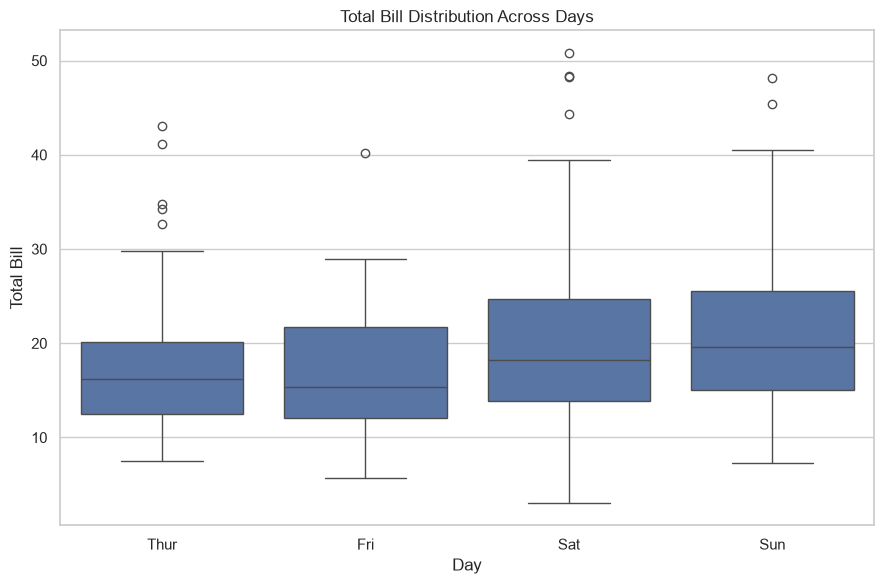

Plot saved successfully to: ..\plots\day04_total_bill_by_day.png


In [40]:
# Boxplot: Total Bill by Day

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="day",
    y="total_bill"
)

plt.title("Total Bill Distribution Across Days")
plt.xlabel("Day")
plt.ylabel("Total Bill")

plt.tight_layout()

plot_file = plots_dir / "day04_total_bill_by_day.png"
plt.savefig(plot_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved successfully to: {plot_file}")

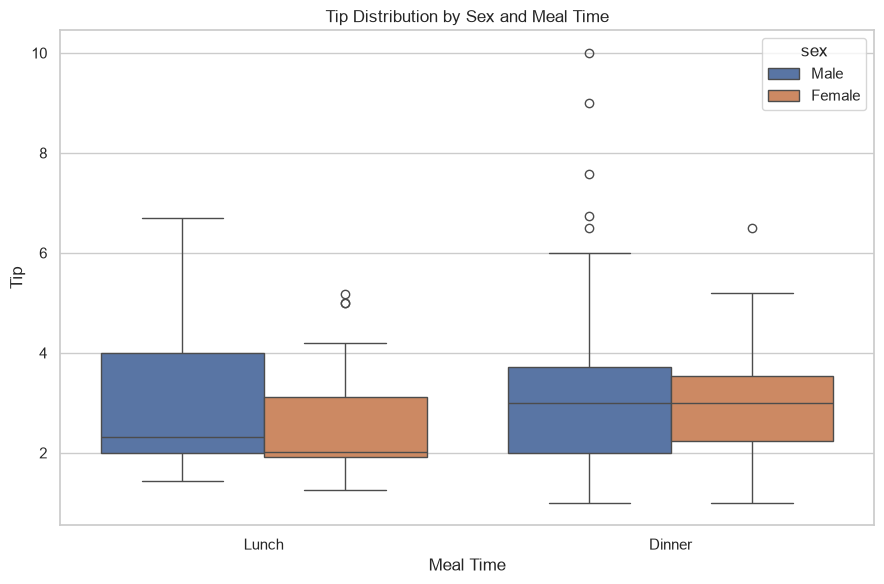

Plot saved successfully to: ..\plots\day04_tip_by_sex_and_time.png


In [41]:
# Interaction Plot: Tip by Sex and Meal Time

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="time",
    y="tip",
    hue="sex"
)

plt.title("Tip Distribution by Sex and Meal Time")
plt.xlabel("Meal Time")
plt.ylabel("Tip")

plt.tight_layout()

plot_file = plots_dir / "day04_tip_by_sex_and_time.png"
plt.savefig(plot_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved successfully to: {plot_file}")

In [42]:
# Verify Day-4 result files

from pathlib import Path

results_dir = Path("../results")

day4_files = [
    "day04_tukey_hsd_results.csv",
    "day04_two_way_anova_results.csv"
]

for file_name in day4_files:
    file_path = results_dir / file_name

    if file_path.exists():
        print(f"✓ Found: {file_name}")
    else:
        print(f"✗ Missing: {file_name}")

✓ Found: day04_tukey_hsd_results.csv
✓ Found: day04_two_way_anova_results.csv
